In [ ]:
'''Data import'''
from pathlib import Path
from urllib.request import urlretrieve

'''Dataframes'''
import pandas as pd

'''Boxplots'''
import matplotlib.pyplot as plt

In [3]:
print(Path.cwd())

c:\Users\moma0\Documents\Weiterbildung\00_GitHub_Repo\Modul3\mle-model-deployment-project\notebooks


In [4]:
'''Collecting RAW data as parquet file'''

url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-01.parquet"

download_dir = Path("./data/raw/")
download_dir.mkdir(parents=True, exist_ok=True)

download_name = download_dir / "yellow_tripdata_2025_01.parquet"

if not download_name.exists():
    urlretrieve(url, download_name)
    print("Download successfull")
    print("File saved to:", download_name)
else:
    print("File already exists")

File already exists


In [5]:
'''Creating list'''

df = pd.read_parquet(download_name)
display(df.head())
df.info()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64   

In [6]:
'''Calculating Duration of trip'''

df["duration"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds()/60

display(df.head(20))
display(df["duration"].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]))

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,duration
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,...,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0,8.350000
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,...,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0,2.550000
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,...,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0,1.950000
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,...,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0,5.566667
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,...,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0,3.533333
5,2,2025-01-01 00:48:24,2025-01-01 01:08:26,2.0,2.63,1.0,N,239,68,2,...,1.0,0.5,0.00,0.0,1.0,24.10,2.5,0.0,0.0,20.033333
6,1,2025-01-01 00:14:47,2025-01-01 00:16:15,0.0,0.40,1.0,N,170,170,1,...,3.5,0.5,2.35,0.0,1.0,11.75,2.5,0.0,0.0,1.466667
7,1,2025-01-01 00:39:27,2025-01-01 00:51:51,0.0,1.60,1.0,N,234,148,1,...,3.5,0.5,2.00,0.0,1.0,19.10,2.5,0.0,0.0,12.400000
8,1,2025-01-01 00:53:43,2025-01-01 01:13:23,0.0,2.80,1.0,N,148,170,1,...,3.5,0.5,3.00,0.0,1.0,27.10,2.5,0.0,0.0,19.666667
9,2,2025-01-01 00:00:02,2025-01-01 00:09:36,1.0,1.71,1.0,N,237,262,2,...,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.0,0.0,9.566667


count    3.475226e+06
mean     1.501812e+01
std      3.871358e+01
min     -5.147232e+04
1%       6.666667e-01
25%      7.283333e+00
50%      1.170000e+01
75%      1.833333e+01
95%      3.620000e+01
99%      5.891667e+01
max      5.626317e+03
Name: duration, dtype: float64

In [7]:
'''Cleaning Data: Define not plausible durations...'''

print("Trips with missing duration:", (df["duration"].isna().sum()))

display(df[df["duration"] > 0].nsmallest(10, "duration")[
    [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "trip_distance",
        "duration"
    ]
])

display(df.nlargest(10, "duration")[
    [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "trip_distance",
        "duration"
    ]
])


'''...and exclude from data frame'''

duration_window = df["duration"].between(1,60)

print("Kept trips:", duration_window.sum())
print("Excluded trips:", (~duration_window).sum())
print(f"Excluded trips [%]: {(~duration_window).mean():.2%}")

df_clean = df[duration_window].copy()
df_clean["duration"].describe()

Trips with missing duration: 0


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,duration
3250,2025-01-01 00:31:53,2025-01-01 00:31:54,0.00,0.016667
15417,2025-01-01 02:30:51,2025-01-01 02:30:52,0.00,0.016667
25316,2025-01-01 08:30:54,2025-01-01 08:30:55,0.00,0.016667
28469,2025-01-01 10:23:59,2025-01-01 10:24:00,0.00,0.016667
75188,2025-01-02 00:36:49,2025-01-02 00:36:50,0.70,0.016667
145338,2025-01-02 21:47:14,2025-01-02 21:47:15,2.61,0.016667
182174,2025-01-03 12:20:15,2025-01-03 12:20:16,0.00,0.016667
265415,2025-01-04 11:13:20,2025-01-04 11:13:21,0.00,0.016667
282864,2025-01-04 14:14:36,2025-01-04 14:14:37,3.50,0.016667
299644,2025-01-04 17:20:04,2025-01-04 17:20:05,0.70,0.016667


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,duration
1858816,2025-01-21 12:23:41,2025-01-25 10:10:00,6.55,5626.316667
1858817,2025-01-21 12:23:41,2025-01-25 10:10:00,6.55,5626.316667
414374,2025-01-06 02:12:11,2025-01-09 13:54:19,91.51,5022.133333
2460536,2025-01-27 11:58:55,2025-01-30 09:42:55,0.00,4184.000000
898201,2025-01-11 08:04:00,2025-01-13 16:49:28,0.04,3405.466667
2147536,2025-01-24 07:07:21,2025-01-26 10:09:44,0.00,3062.383333
85681,2025-01-02 09:40:31,2025-01-04 09:37:01,0.00,2876.500000
1536147,2025-01-17 16:45:49,2025-01-19 16:40:59,1.98,2875.166667
556772,2025-01-07 18:07:33,2025-01-09 16:12:05,1.86,2764.533333
3417048,2025-01-29 21:39:23,2025-01-31 16:48:43,7.52,2589.333333


Kept trips: 3403248
Excluded trips: 71978
Excluded trips [%]: 2.07%


count    3.403248e+06
mean     1.422852e+01
std      9.763400e+00
min      1.000000e+00
25%      7.383333e+00
50%      1.171667e+01
75%      1.818333e+01
max      6.000000e+01
Name: duration, dtype: float64

In [8]:
'''Now checking for akward trip_distance'''
features = ["PULocationID", "DOLocationID", "trip_distance", "duration"]

display(df_clean["trip_distance"].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

display(df_clean[df_clean["trip_distance"] > 0].nsmallest(10, "trip_distance")[features])

display(df_clean[df_clean["trip_distance"] > 0].nlargest(10, "trip_distance")[features])

count    3.403248e+06
mean     5.791339e+00
std      5.694766e+02
min      0.000000e+00
1%       0.000000e+00
10%      6.100000e-01
25%      1.000000e+00
50%      1.680000e+00
75%      3.070000e+00
90%      7.220000e+00
95%      1.105000e+01
99%      1.903000e+01
max      2.764236e+05
Name: trip_distance, dtype: float64

,PULocationID,DOLocationID,trip_distance,duration
4967,186,186,0.01,1.333333
4968,186,164,0.01,1.333333
10045,263,263,0.01,1.216667
10046,263,263,0.01,1.216667
11222,164,164,0.01,1.866667
11627,164,234,0.01,1.383333
11628,164,234,0.01,1.383333
15295,48,48,0.01,3.783333
15296,48,48,0.01,3.783333
39050,68,68,0.01,3.133333


,PULocationID,DOLocationID,trip_distance,duration
3275762,161,170,276423.57,9.0
3188501,224,233,276099.95,7.0
3240337,52,144,222167.49,26.0
3112173,263,48,206137.99,24.0
3374854,50,186,202771.63,13.0
3081597,246,164,189687.43,18.0
3069039,100,90,181139.99,6.0
3312563,42,238,168079.57,11.0
3195037,247,239,167452.94,27.0
3138510,262,239,164959.95,15.0


As seen in the describe above, distances between 0.5 and 20 (miles) cover reasonable and lots of data for training.  \
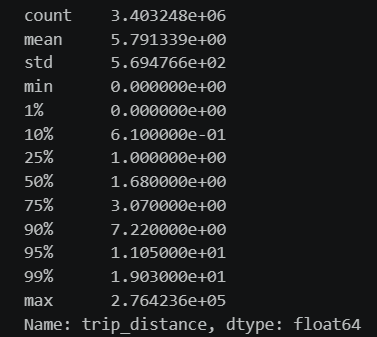

In [9]:
distance_window = df_clean["trip_distance"].between(0.5,20)

df_clean = df_clean[distance_window].copy()

print("Kept trips:", distance_window.sum())
print("Excluded trips:", (~distance_window).sum())
print(f"Excluded trips [%]: {(~distance_window).mean():.2%}")

df_clean["trip_distance"].describe()

Kept trips: 3174647
Excluded trips: 228601
Excluded trips [%]: 6.72%


count    3.174647e+06
mean     3.043851e+00
std      3.531883e+00
min      5.000000e-01
25%      1.100000e+00
50%      1.770000e+00
75%      3.180000e+00
max      2.000000e+01
Name: trip_distance, dtype: float64

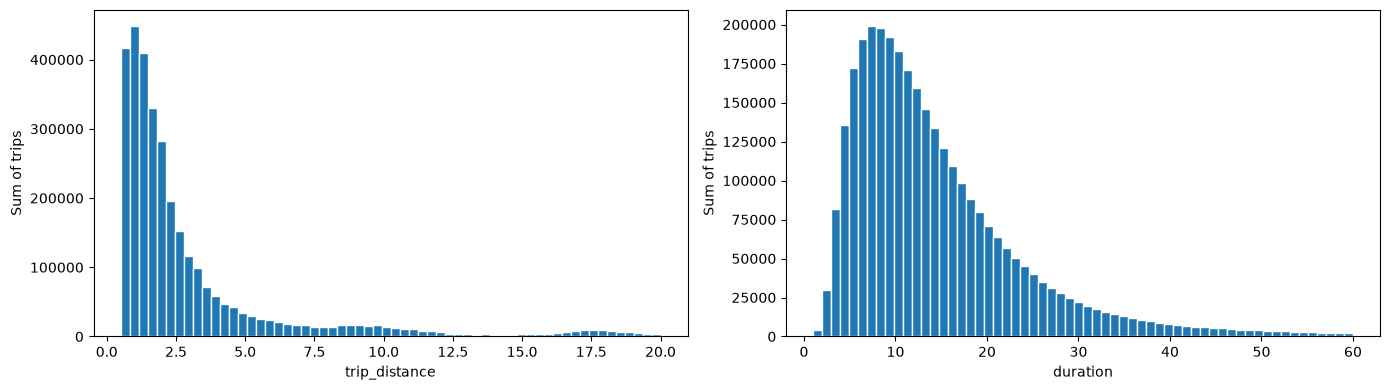

In [10]:
'''Final check of cleaned Dataframe before saving to parquet file'''
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, column in zip(axes, ["trip_distance", "duration"]):
    ax.hist(df_clean[column], bins=60, edgecolor="white")
    ax.set_xlabel(column)
    ax.set_ylabel("Sum of trips")

plt.tight_layout()
plt.show()

In [11]:
'''Saving cleaned DF as parquet'''

cleaned_dir = Path("./data/cleaned/")
cleaned_dir.mkdir(parents=True, exist_ok=True)

cleaned_name = cleaned_dir / "cleaned_yellow_tripdata_2025_01.parquet"

df_clean.to_parquet(cleaned_name, index=False)
print("Saving cleaned dataframe successfull")
print("File saved to:", cleaned_name)

df_clean[["trip_distance", "duration"]].describe()

Saving cleaned dataframe successfull
File saved to: data\cleaned\cleaned_yellow_tripdata_2025_01.parquet


,trip_distance,duration
count,3.174647e+06,3.174647e+06
mean,3.043851e+00,1.442608e+01
std,3.531883e+00,9.434410e+00
min,5.000000e-01,1.000000e+00
25%,1.100000e+00,7.783333e+00
50%,1.770000e+00,1.198333e+01
75%,3.180000e+00,1.831667e+01
max,2.000000e+01,6.000000e+01
